Step 1:Importing Library

In [1]:

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, f1_score, precision_score, recall_score
)


from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Set Plot Style ---
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")
print("Ready to build Fraud Detection Model!")

All libraries imported successfully!
Ready to build Fraud Detection Model!


Step 2: Load the Dataset

In [2]:
df = pd.read_csv('creditcard.csv')

  Step 3: EXPLORATORY DATA ANALYSIS 

In [3]:


# --- 3.1 Basic Dataset Info ---

print('DATASET OVERVIEW')
print(f'Rows : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'Missing Values: {df.isnull().sum().sum()}')
print(f'Duplicate Rows: {df.duplicated().sum():,}')


DATASET OVERVIEW
Rows : 284,807
Columns : 31
Missing Values: 0
Duplicate Rows: 1,081


In [4]:
# --- 3.2 Data Types & Column Info ---
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 

In [5]:
# --- 3.3 Statistical Summary ---
print('Statistical Summary:')
df[['Time', 'Amount']].describe().round(2)

Statistical Summary:


,Time,Amount
count,284807.00,284807.00
mean,94813.86,88.35
std,47488.15,250.12
min,0.00,0.00
25%,54201.50,5.60
50%,84692.00,22.00
75%,139320.50,77.16
max,172792.00,25691.16


Normal transactions : 284315
Fraud transactions  : 492


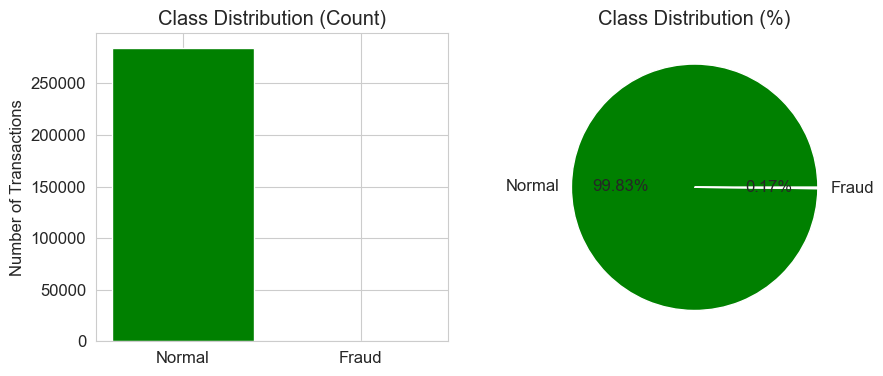

In [6]:
# Class Distribution

# Count transactions
counts = df['Class'].value_counts()

print("Normal transactions :", counts[0])
print("Fraud transactions  :", counts[1])

# Bar chart
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(['Normal','Fraud'], counts, color=['green','red'])
plt.title("Class Distribution (Count)")
plt.ylabel("Number of Transactions")

# Pie chart
plt.subplot(1,2,2)
plt.pie(counts, labels=['Normal','Fraud'], autopct='%1.2f%%', colors=['green','red'])
plt.title("Class Distribution (%)")

plt.show()

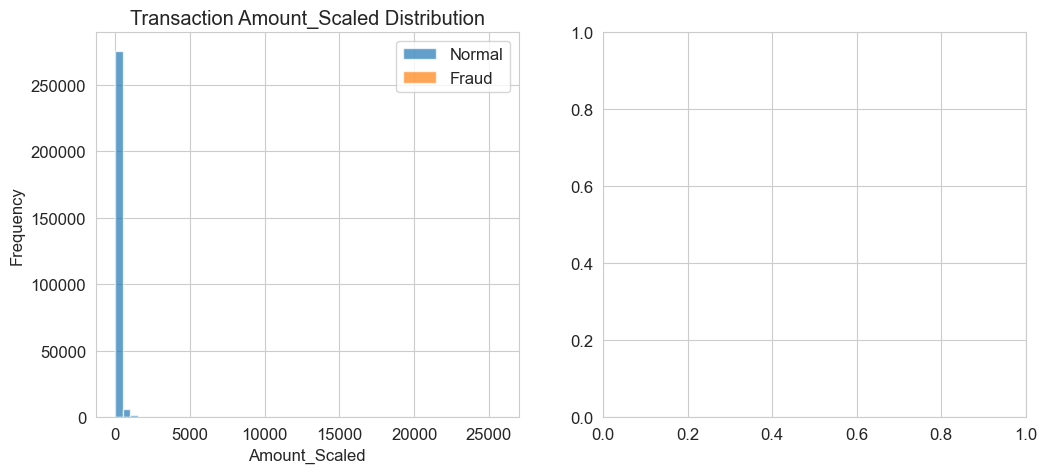

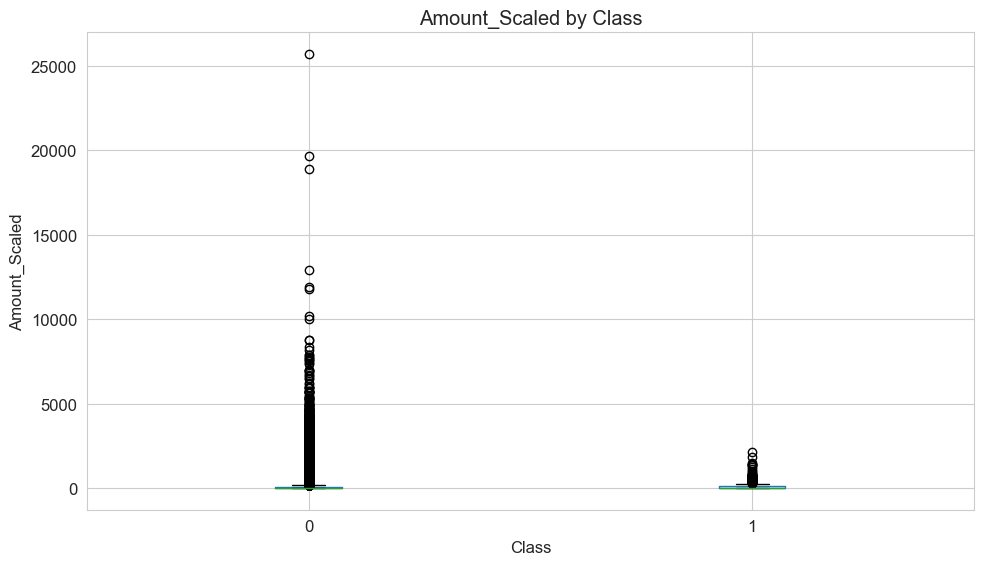

Avg Normal Transaction Amount: 88.29102242231328
Avg Fraud Transaction Amount: 122.21132113821139


In [11]:
# Transaction Amount_Scaled Analysis

plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
plt.hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, label='Normal')
plt.hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, label='Fraud')
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()

# Boxplot
plt.subplot(1,2,2)
df.boxplot(column='Amount', by='Class')
plt.title("Amount_Scaled by Class")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.suptitle("")

plt.tight_layout()
plt.show()

# Average values
print("Avg Normal Transaction Amount:", df[df["Class"]==0]["Amount"].mean())
print("Avg Fraud Transaction Amount:", df[df["Class"]==1]["Amount"].mean())

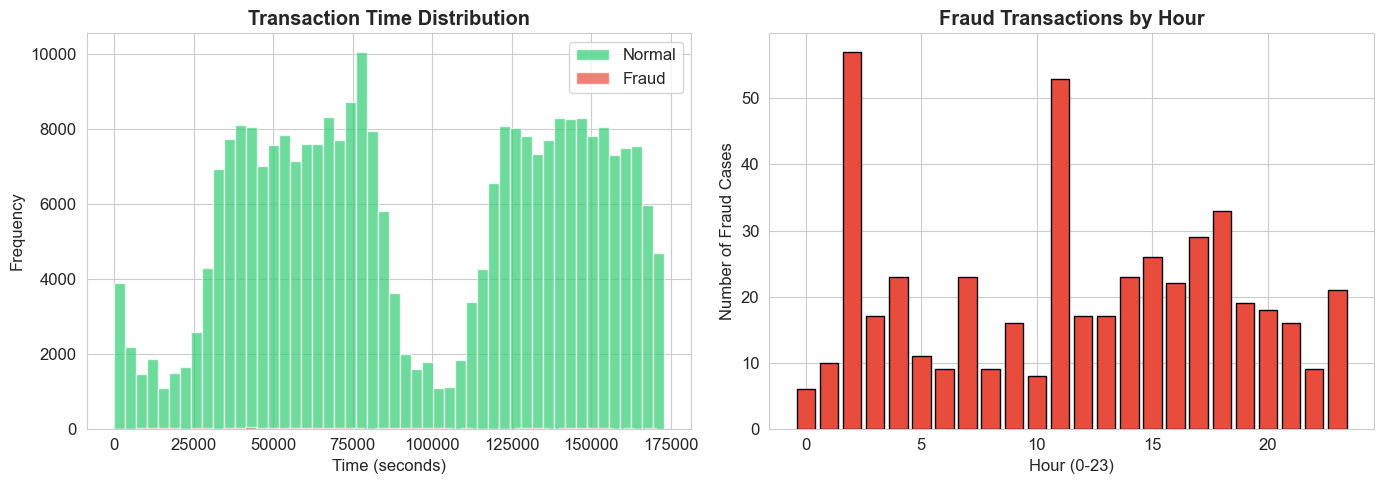

Fraud occurs more during late night / early morning hours!


In [13]:
# --- 3.6 Transaction Time Analysis ---
df['Hour'] = (df['Time'] / 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time distribution
axes[0].hist(df[df['Class']==0]['Time'], bins=50,
             color='#2ecc71', alpha=0.7, label='Normal')
axes[0].hist(df[df['Class']==1]['Time'], bins=50,
             color='#e74c3c', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Time Distribution', fontweight='bold')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Fraud by hour
fraud_by_hour = df[df['Class']==1].groupby(
                df['Hour'].astype(int)).size()
axes[1].bar(fraud_by_hour.index, fraud_by_hour.values,
            color='#e74c3c', edgecolor='black')
axes[1].set_title('Fraud Transactions by Hour', fontweight='bold')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Number of Fraud Cases')

plt.tight_layout()
plt.show()
print('Fraud occurs more during late night / early morning hours!')

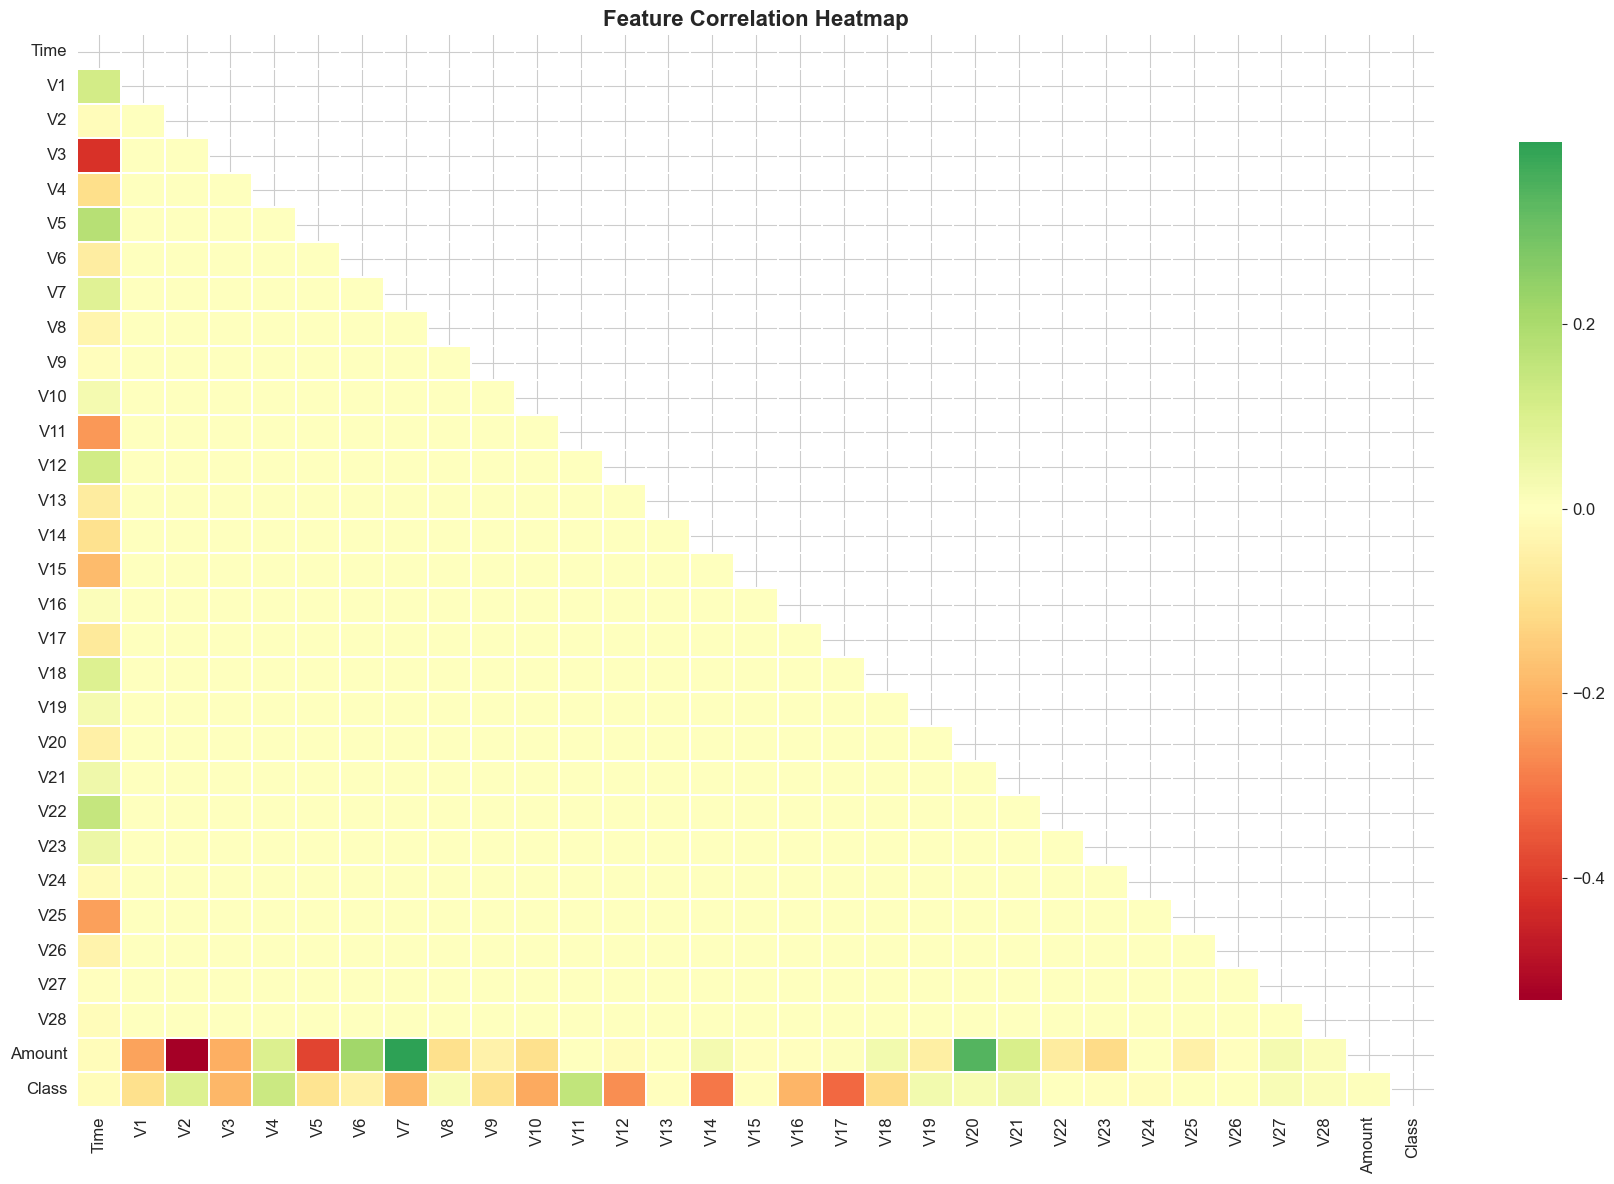

In [14]:
# --- 3.7 Correlation Heatmap ---
plt.figure(figsize=(18, 12))
corr = df.drop(columns=['Hour']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn',
            center=0, linewidths=0.3,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

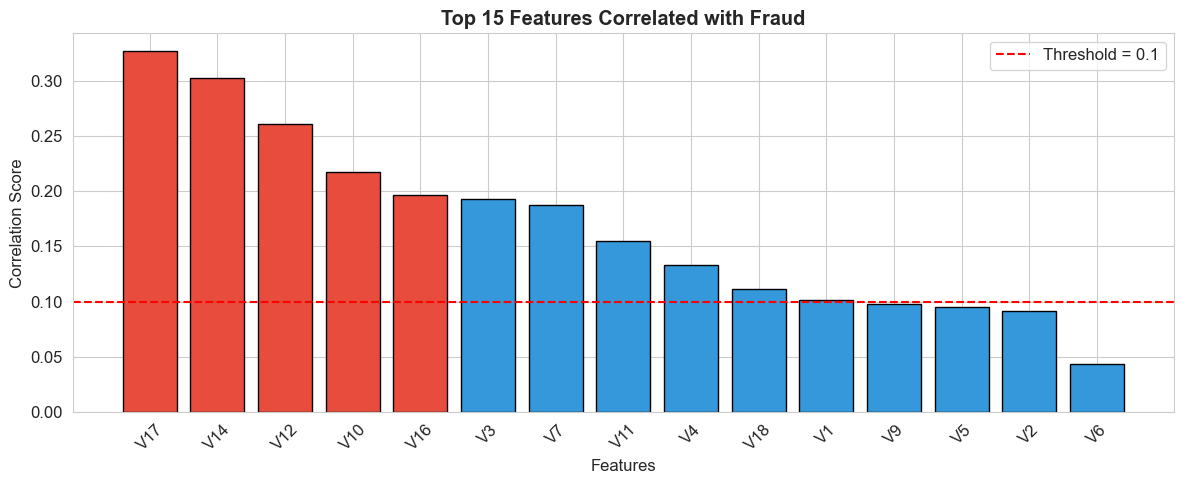

In [15]:
# --- 3.8 Top Features Correlated with Fraud ---
corr_with_fraud = df.drop(columns=['Hour']).corr()['Class']\
                    .drop('Class').abs()\
                    .sort_values(ascending=False)

plt.figure(figsize=(12, 5))
colors_bar = ['#e74c3c' if i < 5 else '#3498db'
              for i in range(15)]
plt.bar(corr_with_fraud.index[:15],
        corr_with_fraud.values[:15],
        color=colors_bar, edgecolor='black')
plt.title('Top 15 Features Correlated with Fraud',
          fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Correlation Score')
plt.xticks(rotation=45)
plt.axhline(y=0.1, color='red', linestyle='--',
            label='Threshold = 0.1')
plt.legend()
plt.tight_layout()
plt.show()


STEP 4: DATA PREPROCESSING

In [16]:

# --- 4.1 Remove Duplicate Rows ---
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f'Duplicate Rows Removed : {before - after:,}')
print(f'Rows Before : {before:,}')
print(f'Rows After  : {after:,}')


Duplicate Rows Removed : 1,081
Rows Before : 284,807
Rows After  : 283,726


In [17]:
# --- 4.2 Drop Helper Column ---
# We created 'Hour' column in EDA step
# We don't need it for training the model
df = df.drop(columns=['Hour'], errors='ignore')

print(f'Columns now : {df.shape[1]}')
print(f'Column List : {list(df.columns)}')

Columns now : 31
Column List : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [20]:
# --- 4.3 Scale Amount and Time ---
# V1-V28 are already scaled (PCA transformed)
# But Amount and Time are NOT scaled → we scale them

scaler = StandardScaler()

df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled']   = scaler.fit_transform(df[['Time']])

df.drop(columns=['Amount', 'Time'], inplace=True)

print('Amount and Time scaled successfully!')
print(f'Final Columns : {list(df.columns)}')
print(f'Dataset Shape : {df.shape}')

Amount and Time scaled successfully!
Final Columns : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_Scaled', 'Time_Scaled']
Dataset Shape : (283726, 31)


In [21]:
# --- 4.4 Split Features (X) and Target (y) ---
X = df.drop(columns=['Class'])   # everything except Class
y = df['Class']                  # only Class column

print(f'Features (X) shape : {X.shape}')
print(f'Target   (y) shape : {y.shape}')
print(f'\nClass Distribution in y:')
print(f'Normal (0) : {(y==0).sum():,}')
print(f'Fraud  (1) : {(y==1).sum():,}')

Features (X) shape : (283726, 30)
Target   (y) shape : (283726,)

Class Distribution in y:
Normal (0) : 283,253
Fraud  (1) : 473


Train-Test Split Completed
Training rows : 226980
Testing rows  : 56746
Train fraud % : 0.16653449643140364
Test fraud %  : 0.16741268107003138


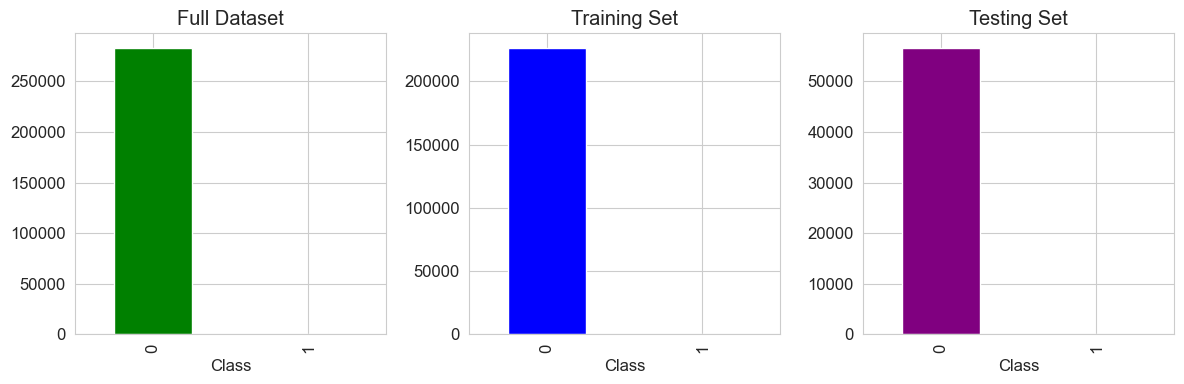

In [22]:
# --- 4.5 Train Test Split ---


# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train-Test Split Completed")
print("Training rows :", X_train.shape[0])
print("Testing rows  :", X_test.shape[0])

print("Train fraud % :", y_train.mean()*100)
print("Test fraud %  :", y_test.mean()*100)

# Visualize the split
plt.figure(figsize=(12,4))

# Full dataset
plt.subplot(1,3,1)
y.value_counts().plot(kind='bar', color=['green','red'])
plt.title("Full Dataset")

# Training set
plt.subplot(1,3,2)
y_train.value_counts().plot(kind='bar', color=['blue','orange'])
plt.title("Training Set")

# Testing set
plt.subplot(1,3,3)
y_test.value_counts().plot(kind='bar', color=['purple','cyan'])
plt.title("Testing Set")

plt.tight_layout()
plt.show()

 STEP 5: HANDLE IMBALANCED DATA
         SMOTE + UNDERSAMPLING

In [23]:

# --- 5.1 Check imbalance before balancing ---
print('Before Balancing:')
print(f'   Normal (0) : {(y_train==0).sum():,}')
print(f'   Fraud  (1) : {(y_train==1).sum():,}')
print(f'   Fraud  %   : {y_train.mean()*100:.2f}%')

Before Balancing:
   Normal (0) : 226,602
   Fraud  (1) : 378
   Fraud  %   : 0.17%


In [24]:
# --- 5.2 Apply SMOTE + Undersampling ---

# Step 1: SMOTE → increase fraud samples
smote = SMOTE(
    sampling_strategy = 0.5,   # make fraud = 50% of normal
    random_state      = 42
)

# Step 2: Undersampler → reduce normal samples
under = RandomUnderSampler(
    sampling_strategy = 0.8,   # make fraud = 80% of normal
    random_state      = 42
)

# Step 3: Combine both in a pipeline
pipeline = ImbPipeline([
    ('smote', smote),
    ('under', under)
])

# Step 4: Apply on TRAINING data only!
X_train_bal, y_train_bal = pipeline.fit_resample(
    X_train, y_train
)

print('SMOTE + Undersampling Applied Successfully!')

SMOTE + Undersampling Applied Successfully!


In [25]:
# --- 5.3 Check balance after balancing ---
print('After Balancing:')
print(f'Normal (0) : {(y_train_bal==0).sum():,}')
print(f'Fraud  (1) : {(y_train_bal==1).sum():,}')
print(f'Fraud  %   : {y_train_bal.mean()*100:.2f}%')


After Balancing:
Normal (0) : 141,626
Fraud  (1) : 113,301
Fraud  %   : 44.44%


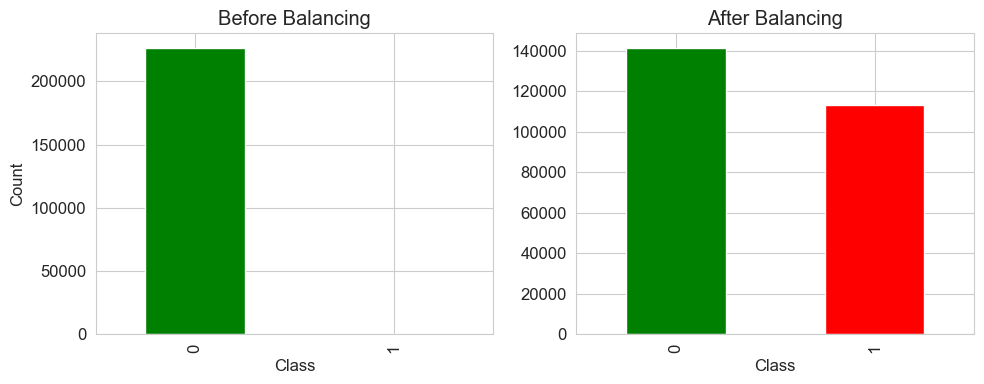

In [26]:
# --- 5.4 Visualize Before vs After ---
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10,4))

# Before balancing
plt.subplot(1,2,1)
y_train.value_counts().plot(kind='bar', color=['green','red'])
plt.title("Before Balancing")
plt.xlabel("Class")
plt.ylabel("Count")

# After balancing
plt.subplot(1,2,2)
pd.Series(y_train_bal).value_counts().plot(kind='bar', color=['green','red'])
plt.title("After Balancing")

plt.tight_layout()
plt.show()

In [27]:
# --- 5.5 Confirm test data is NOT balanced ---
# Very important! Never apply SMOTE on test data!
print('Test Data is kept ORIGINAL (not balanced):')
print(f'   Normal (0) : {(y_test==0).sum():,}')
print(f'   Fraud  (1) : {(y_test==1).sum():,}')
print(f'\nTraining data : BALANCED  (for model to learn)')
print(f'Testing  data : ORIGINAL  (for real evaluation)')

Test Data is kept ORIGINAL (not balanced):
   Normal (0) : 56,651
   Fraud  (1) : 95

Training data : BALANCED  (for model to learn)
Testing  data : ORIGINAL  (for real evaluation)


STEP 6: BUILD & TRAIN ML MODELS

In [28]:

# --- 6.1 Define All Models ---
models = {

    'Logistic Regression': LogisticRegression(
        class_weight = 'balanced',
        max_iter     = 1000,
        random_state = 42
    ),

    'Decision Tree': DecisionTreeClassifier(
        class_weight = 'balanced',
        max_depth    = 10,
        random_state = 42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators = 100,
        class_weight = 'balanced',
        max_depth    = 15,
        random_state = 42,
        n_jobs       = -1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators  = 100,
        max_depth     = 5,
        learning_rate = 0.1,
        random_state  = 42
    )

}

print('Models Ready to Train:')
for name in models:
    print(f'{name}')
    

Models Ready to Train:
Logistic Regression
Decision Tree
Random Forest
Gradient Boosting


In [29]:
# --- 6.2 Train All Models & Collect Results ---
results = {}

for name, model in models.items():

    print(f'\nTraining {name}...')

    # --- Train the model ---
    model.fit(X_train_bal, y_train_bal)

    # --- Make predictions ---
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # --- Calculate all metrics ---
    acc       = accuracy_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)

    # --- Store results ---
    results[name] = {
        'model'     : model,
        'y_pred'    : y_pred,
        'y_prob'    : y_pred_prob,
        'Accuracy'  : round(acc * 100, 2),
        'Precision' : round(precision * 100, 2),
        'Recall'    : round(recall * 100, 2),
        'F1 Score'  : round(f1 * 100, 2),
        'ROC AUC'   : round(roc_auc * 100, 2)
    }

    print(f'Accuracy  : {acc*100:.2f}%')
    print(f'Precision : {precision*100:.2f}%')
    print(f'Recall    : {recall*100:.2f}%')
    print(f'F1 Score  : {f1*100:.2f}%')
    print(f'ROC-AUC   : {roc_auc*100:.2f}%')

print('\n All Models Trained Successfully!')


Training Logistic Regression...
Accuracy  : 97.38%
Precision : 5.33%
Recall    : 87.37%
F1 Score  : 10.04%
ROC-AUC   : 96.16%

Training Decision Tree...
Accuracy  : 98.79%
Precision : 10.09%
Recall    : 78.95%
F1 Score  : 17.90%
ROC-AUC   : 85.45%

Training Random Forest...
Accuracy  : 99.93%
Precision : 78.72%
Recall    : 77.89%
F1 Score  : 78.31%
ROC-AUC   : 97.37%

Training Gradient Boosting...
Accuracy  : 99.73%
Precision : 36.92%
Recall    : 83.16%
F1 Score  : 51.13%
ROC-AUC   : 97.33%

 All Models Trained Successfully!


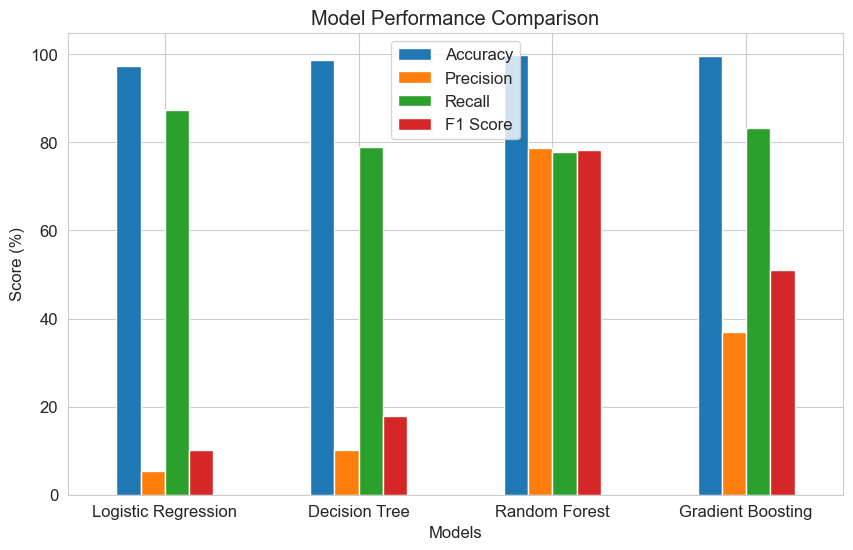

In [30]:
# --- 6.3 Training Progress Visualization ---

# Convert results dictionary to dataframe
results_df = pd.DataFrame(results).T

# Plot comparison
results_df[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar', figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score (%)")
plt.xlabel("Models")
plt.xticks(rotation=0)
plt.legend()
plt.show()

 STEP 7: MODEL COMPARISON & RESULTS

In [31]:

# --- 7.1 Build Comparison Table ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

results_df = pd.DataFrame(
    {name: {m: results[name][m] for m in metrics}
     for name in results}
).T

print('=' * 70)
print('              MODEL COMPARISON RESULTS (%)')
print('=' * 70)
print(results_df.to_string())
print('=' * 70)

              MODEL COMPARISON RESULTS (%)
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression     97.38       5.33   87.37     10.04    96.16
Decision Tree           98.79      10.09   78.95     17.90    85.45
Random Forest           99.93      78.72   77.89     78.31    97.37
Gradient Boosting       99.73      36.92   83.16     51.13    97.33


In [32]:
# --- 7.2 Find Best Model for Each Metric ---
print('\nBest Model for Each Metric:')
print('-' * 45)
for metric in metrics:
    best_name  = results_df[metric].idxmax()
    best_score = results_df[metric].max()
    print(f'   {metric:<15} → {best_name:<25} ({best_score}%)')
print('-' * 45)

# Overall best model by ROC AUC
best_model_name = results_df['ROC AUC'].idxmax()
print(f'\n Overall Best Model : {best_model_name}')
print(f'   ROC AUC Score     : {results_df.loc[best_model_name, "ROC AUC"]}%')


Best Model for Each Metric:
---------------------------------------------
   Accuracy        → Random Forest             (99.93%)
   Precision       → Random Forest             (78.72%)
   Recall          → Logistic Regression       (87.37%)
   F1 Score        → Random Forest             (78.31%)
   ROC AUC         → Random Forest             (97.37%)
---------------------------------------------

 Overall Best Model : Random Forest
   ROC AUC Score     : 97.37%


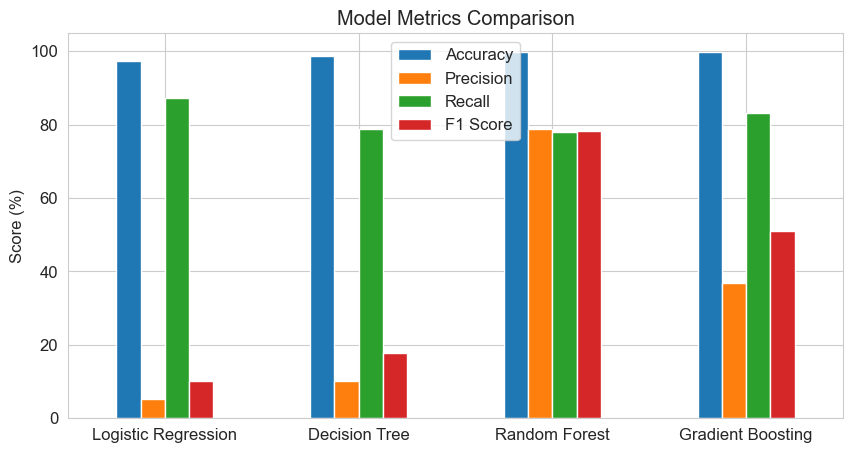

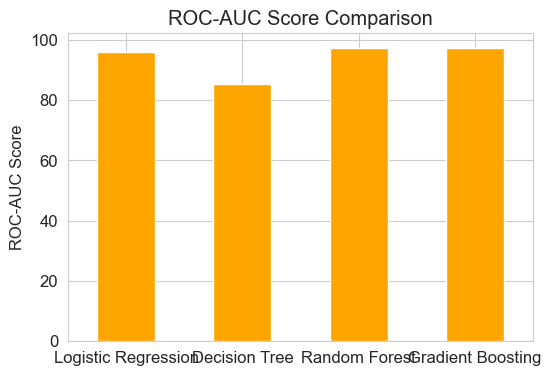

In [33]:
# --- 7.3 Metrics Comparison Bar Chart ---
import matplotlib.pyplot as plt

# Metrics comparison
results_df[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Model Metrics Comparison")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.show()


# ROC-AUC comparison
results_df['ROC AUC'].plot(
    kind='bar',
    figsize=(6,4),
    color='orange'
)

plt.title("ROC-AUC Score Comparison")
plt.ylabel("ROC-AUC Score")
plt.xticks(rotation=0)
plt.show()

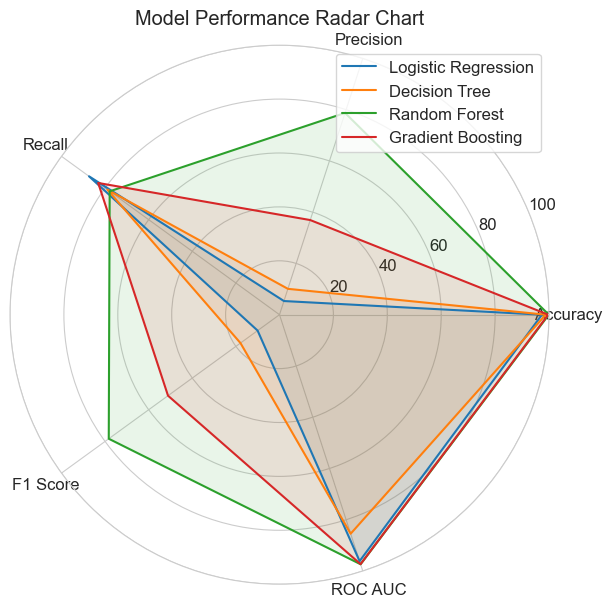

In [34]:
# --- 7.4 Radar Chart (Spider Chart) ---
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

for model, values in results.items():
    
    data = [values[c] for c in categories]
    data += data[:1]
    
    ax.plot(angles, data, label=model)
    ax.fill(angles, data, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

ax.set_ylim(0,100)

plt.title("Model Performance Radar Chart")
plt.legend(loc='upper right')

plt.show()

In [35]:
# --- 7.5 Final Ranking Table ---
print('\nFinal Model Ranking (by ROC AUC):')
print('=' * 55)

ranked = results_df.sort_values('ROC AUC', ascending=False)


for i, (name, row) in enumerate(ranked.iterrows()):
    print(f'\n{name}')
    print(f'Accuracy  : {row["Accuracy"]}%')
    print(f'Precision : {row["Precision"]}%')
    print(f'Recall    : {row["Recall"]}%')
    print(f'F1 Score  : {row["F1 Score"]}%')
    print(f'ROC AUC   : {row["ROC AUC"]}%')




Final Model Ranking (by ROC AUC):

Random Forest
Accuracy  : 99.93%
Precision : 78.72%
Recall    : 77.89%
F1 Score  : 78.31%
ROC AUC   : 97.37%

Gradient Boosting
Accuracy  : 99.73%
Precision : 36.92%
Recall    : 83.16%
F1 Score  : 51.13%
ROC AUC   : 97.33%

Logistic Regression
Accuracy  : 97.38%
Precision : 5.33%
Recall    : 87.37%
F1 Score  : 10.04%
ROC AUC   : 96.16%

Decision Tree
Accuracy  : 98.79%
Precision : 10.09%
Recall    : 78.95%
F1 Score  : 17.9%
ROC AUC   : 85.45%


STEP 8: CONFUSION MATRIX

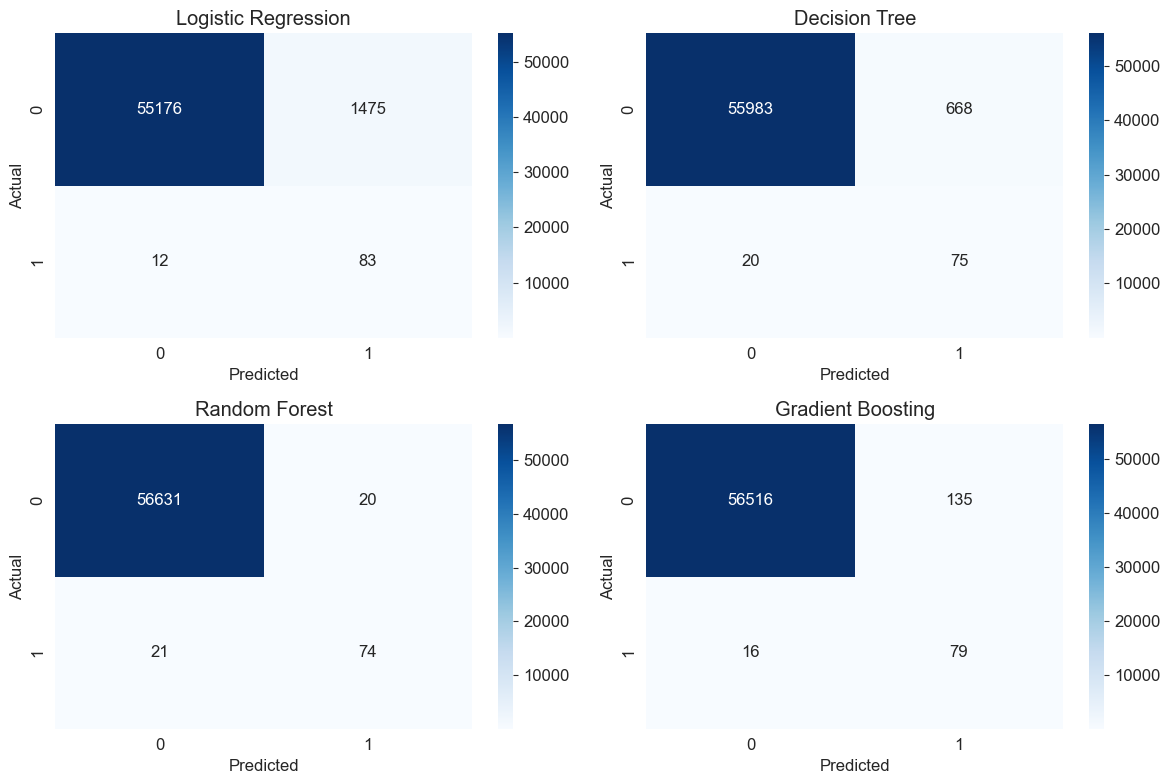

In [36]:

# --- 8.1 Confusion Matrix for All Models ---
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(12,8))

for i, (model, res) in enumerate(results.items(), 1):
    
    plt.subplot(2,2,i)
    
    cm = confusion_matrix(y_test, res['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    
    plt.title(model)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [37]:
# --- 8.2 Detailed TP, TN, FP, FN for Each Model ---
from sklearn.metrics import confusion_matrix

print("Confusion Matrix Breakdown")

for model, res in results.items():
    
    tn, fp, fn, tp = confusion_matrix(y_test, res['y_pred']).ravel()
    
    print("\nModel:", model)
    print("True Negative :", tn)
    print("False Positive:", fp)
    print("False Negative:", fn)
    print("True Positive :", tp)

Confusion Matrix Breakdown

Model: Logistic Regression
True Negative : 55176
False Positive: 1475
False Negative: 12
True Positive : 83

Model: Decision Tree
True Negative : 55983
False Positive: 668
False Negative: 20
True Positive : 75

Model: Random Forest
True Negative : 56631
False Positive: 20
False Negative: 21
True Positive : 74

Model: Gradient Boosting
True Negative : 56516
False Positive: 135
False Negative: 16
True Positive : 79


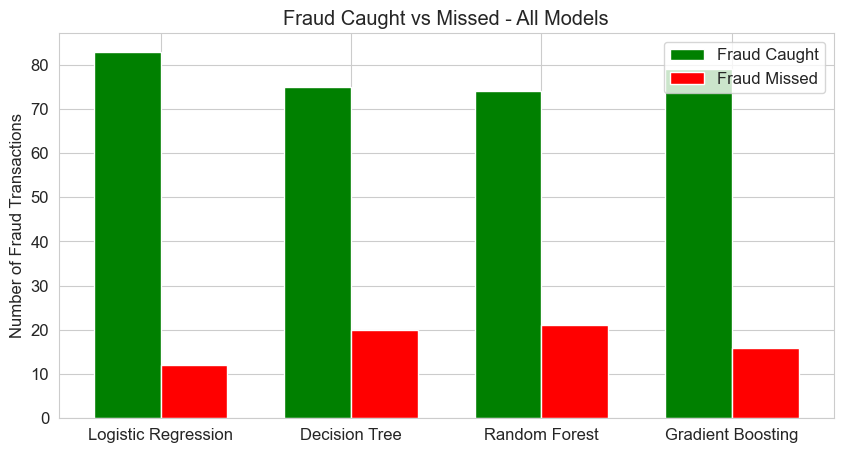

In [38]:
# --- 8.3 Compare Fraud Caught vs Missed ---
models = list(results.keys())

caught = []
missed = []

for model in models:
    tn, fp, fn, tp = confusion_matrix(y_test, results[model]['y_pred']).ravel()
    caught.append(tp)
    missed.append(fn)

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2, caught, width, label="Fraud Caught", color="green")
plt.bar(x + width/2, missed, width, label="Fraud Missed", color="red")

plt.xticks(x, models)
plt.ylabel("Number of Fraud Transactions")
plt.title("Fraud Caught vs Missed - All Models")
plt.legend()

plt.show()

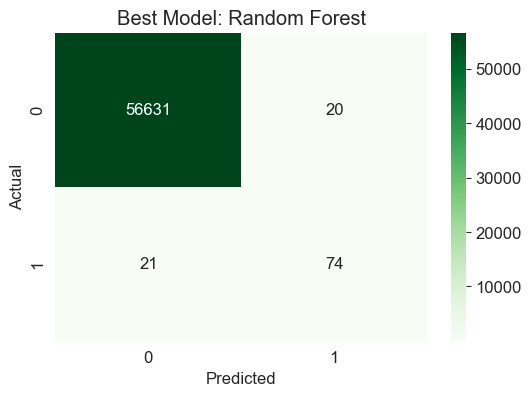

Best Model: Random Forest
Fraud caught: 74
Fraud missed: 21
Catch rate: 77.89 %


In [39]:
# --- 8.4 Best Model Confusion Matrix (Enlarged) ---
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_res = results[best_model_name]

cm = confusion_matrix(y_test, best_res['y_pred'])

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title(f"Best Model: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

tn, fp, fn, tp = cm.ravel()

print("Best Model:", best_model_name)
print("Fraud caught:", tp)
print("Fraud missed:", fn)
print("Catch rate:", round(tp/(tp+fn)*100,2), "%")

   STEP 9: ROC CURVE & PRECISION-RECALL CURVE

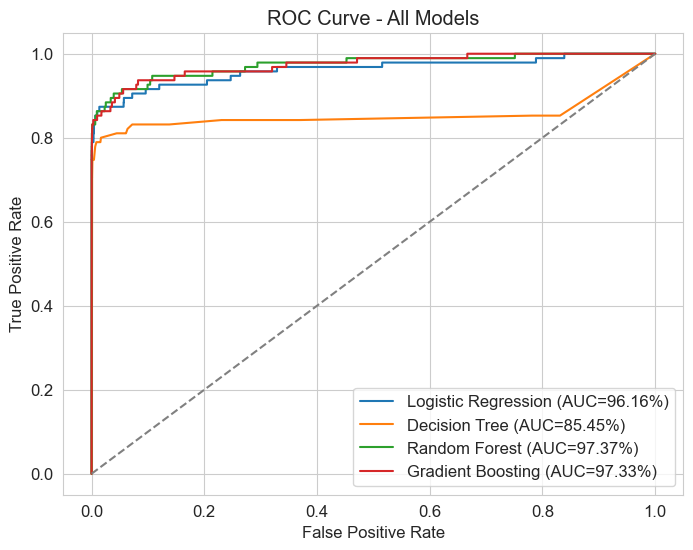

In [40]:

# --- 9.1 ROC Curve for All Models ---
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for model, res in results.items():
    
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    
    plt.plot(fpr, tpr, label=f"{model} (AUC={res['ROC AUC']}%)")

# Random classifier line
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models")
plt.legend()

plt.show()

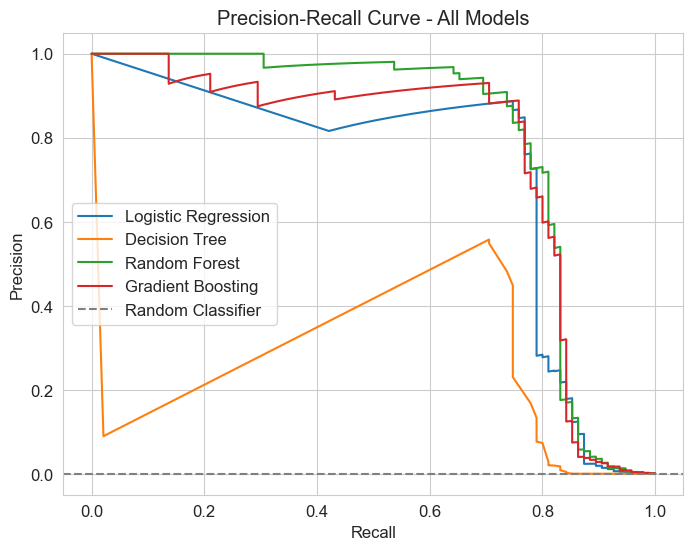

In [41]:
# --- 9.2 Precision-Recall Curve for All Models ---
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for model, res in results.items():
    
    precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
    
    plt.plot(recall, precision, label=model)

# Random baseline
baseline = sum(y_test)/len(y_test)
plt.axhline(baseline, linestyle="--", color="gray", label="Random Classifier")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - All Models")
plt.legend()

plt.show()

In [42]:
# --- 9.3 AUC Score Comparison ---
print('       ROC-AUC SCORE COMPARISON')
for name, res in results.items():
    print(f'  {name:<25} : {res["ROC AUC"]}%')



       ROC-AUC SCORE COMPARISON
  Logistic Regression       : 96.16%
  Decision Tree             : 85.45%
  Random Forest             : 97.37%
  Gradient Boosting         : 97.33%


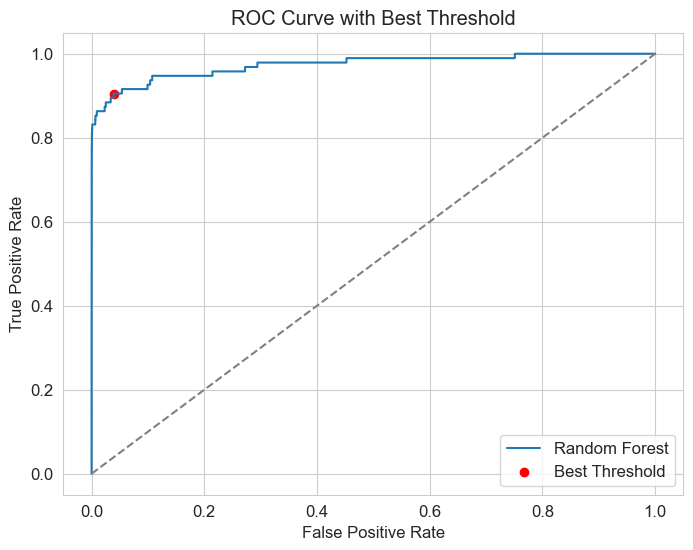

Best Threshold: 0.05499770683405946


In [43]:
# --- 9.4 Threshold Analysis for Best Model ---
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np

best_res = results[best_model_name]

fpr, tpr, thresholds = roc_curve(y_test, best_res['y_prob'])

# Find best threshold
idx = np.argmax(tpr - fpr)
best_threshold = thresholds[idx]

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=best_model_name)
plt.plot([0,1],[0,1],'--', color='gray')

plt.scatter(fpr[idx], tpr[idx], color='red', label="Best Threshold")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Best Threshold")
plt.legend()

plt.show()

print("Best Threshold:", best_threshold)

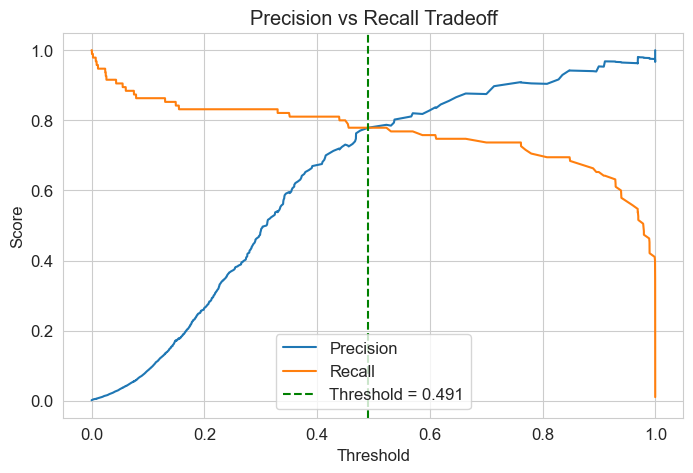

Best Threshold: 0.4906904251253089


In [44]:
# --- 9.5 Precision Recall Tradeoff for Best Model ---
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

best_res = results[best_model_name]

precision, recall, thresholds = precision_recall_curve(y_test, best_res['y_prob'])

plt.figure(figsize=(8,5))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

# Find crossover threshold (precision ≈ recall)
diff = np.abs(precision[:-1] - recall[:-1])
idx = np.argmin(diff)
best_threshold = thresholds[idx]

# Draw threshold line
plt.axvline(best_threshold, color='green', linestyle='--',
            label=f"Threshold = {best_threshold:.3f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall Tradeoff")
plt.legend()

plt.show()

print("Best Threshold:", best_threshold)

  STEP 10: BEST MODEL DEEP ANALYSIS & FEATURE IMPORTANCE

In [45]:

# --- 10.1 Full Classification Report ---
best_res = results[best_model_name]

print(f'BEST MODEL : {best_model_name}')

print(f'Accuracy  : {best_res["Accuracy"]}%')
print(f'Precision : {best_res["Precision"]}%')
print(f'Recall    : {best_res["Recall"]}%')
print(f'F1 Score  : {best_res["F1 Score"]}%')
print(f'ROC AUC   : {best_res["ROC AUC"]}%')

print('\nFull Classification Report:')
print(classification_report(
    y_test,
    best_res['y_pred'],
    target_names = ['Normal (0)', 'Fraud (1)']
))

BEST MODEL : Random Forest
Accuracy  : 99.93%
Precision : 78.72%
Recall    : 77.89%
F1 Score  : 78.31%
ROC AUC   : 97.37%

Full Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56651
   Fraud (1)       0.79      0.78      0.78        95

    accuracy                           1.00     56746
   macro avg       0.89      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746



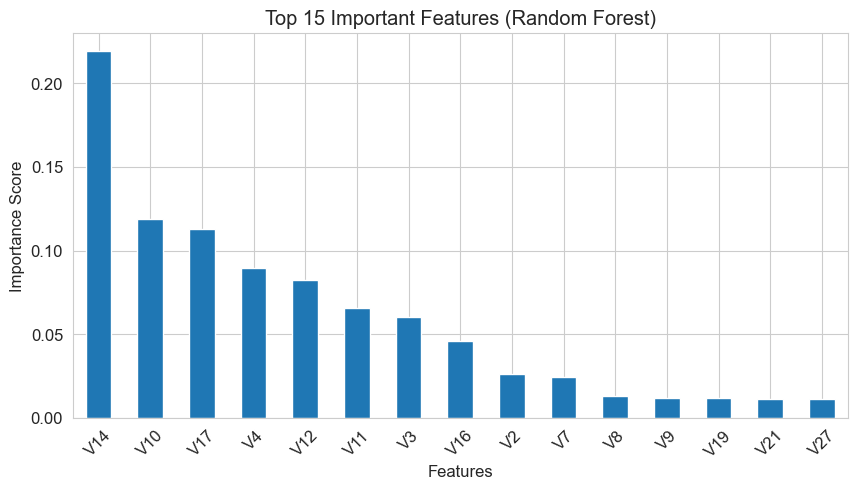

In [46]:
# --- 10.2 Feature Importance ---
best_model = best_res['model']

if hasattr(best_model, "feature_importances_"):
    
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(10,5))
    
    importances.head(15).plot(kind='bar')
    
    plt.title(f"Top 15 Important Features ({best_model_name})")
    plt.xlabel("Features")
    plt.ylabel("Importance Score")
    
    plt.xticks(rotation=45)
    plt.show()

else:
    print("Feature importance not available for this model")

In [47]:
# --- 10.3 Top 10 Features Table ---

# Create feature importance series
feat_imp = pd.Series(best_res['model'].feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print("TOP 10 MOST IMPORTANT FEATURES")
print("="*40)
print("Rank   Feature        Importance")
print("-"*40)

for i, (feature, value) in enumerate(feat_imp.head(10).items(), 1):
    print(f"{i:<5} {feature:<12} {value:.4f}")


TOP 10 MOST IMPORTANT FEATURES
Rank   Feature        Importance
----------------------------------------
1     V14          0.2190
2     V10          0.1189
3     V17          0.1129
4     V4           0.0897
5     V12          0.0827
6     V11          0.0660
7     V3           0.0603
8     V16          0.0461
9     V2           0.0263
10    V7           0.0244


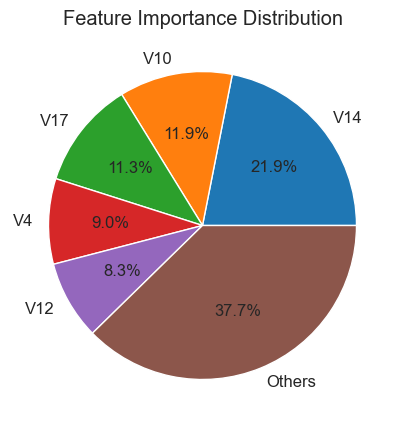

In [48]:
# --- 10.4 Feature Importance Pie Chart ---
# Top 5 features
top5 = feat_imp.head(5)
others = feat_imp[5:].sum()

labels = list(top5.index) + ["Others"]
values = list(top5.values) + [others]

plt.figure(figsize=(7,5))

plt.pie(values, labels=labels, autopct="%1.1f%%")

plt.title("Feature Importance Distribution")
plt.show()

In [49]:
# --- 10.5 Prediction Examples ---

print(' SAMPLE PREDICTIONS ON TEST DATA')

print(f'  {"Index":<8} {"Actual":<12} {"Predicted":<12}'
      f' {"Fraud Probability":<20} {"Result"}')
print('-' * 65)

# Show 5 correct fraud detections
fraud_idx = np.where(
    (y_test.values == 1) &
    (best_res['y_pred'] == 1)
)[0][:5]

for idx in fraud_idx:
    actual    = y_test.values[idx]
    predicted = best_res['y_pred'][idx]
    prob      = best_res['y_prob'][idx]
    result    = 'Correct'
    print(f'  {idx:<8} {"Fraud":<12} {"Fraud":<12}'
          f' {prob:<20.4f} {result}')

print()

# Show 5 missed fraud cases
missed_idx = np.where(
    (y_test.values == 1) &
    (best_res['y_pred'] == 0)
)[0][:5]

for idx in missed_idx:
    actual    = y_test.values[idx]
    predicted = best_res['y_pred'][idx]
    prob      = best_res['y_prob'][idx]
    result    = 'Missed'
    print(f'  {idx:<8} {"Fraud":<12} {"Normal":<12}'
          f' {prob:<20.4f} {result}')

print('=' * 65)

 SAMPLE PREDICTIONS ON TEST DATA
  Index    Actual       Predicted    Fraud Probability    Result
-----------------------------------------------------------------
  845      Fraud        Fraud        0.9899               Correct
  1339     Fraud        Fraud        0.9399               Correct
  2146     Fraud        Fraud        0.8897               Correct
  4865     Fraud        Fraud        0.9393               Correct
  5638     Fraud        Fraud        0.9999               Correct

  1784     Fraud        Normal       0.4547               Missed
  4480     Fraud        Normal       0.0434               Missed
  5187     Fraud        Normal       0.0005               Missed
  5505     Fraud        Normal       0.3300               Missed
  10087    Fraud        Normal       0.1492               Missed


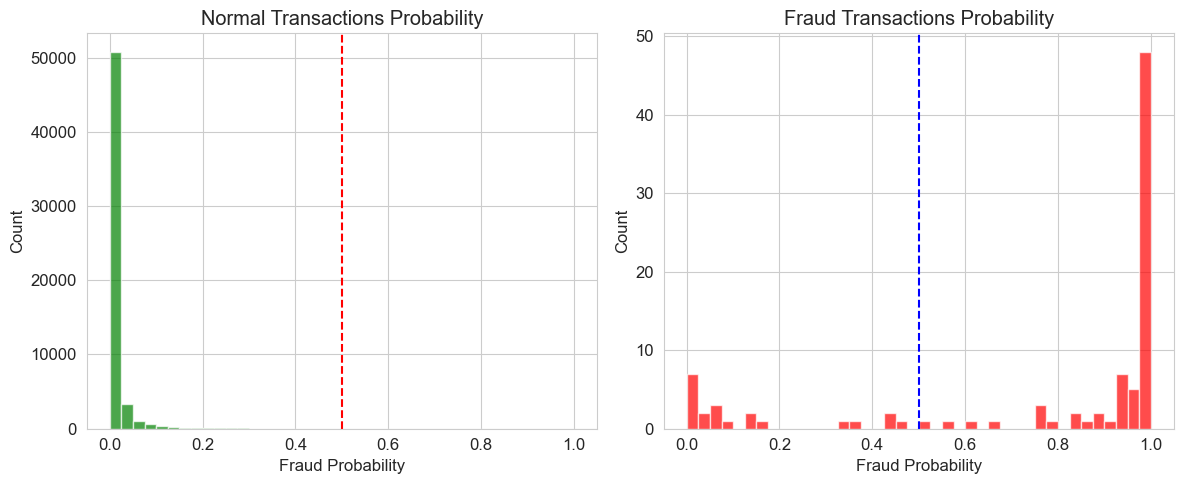

In [50]:
# --- 10.6 Probability Distribution of Predictions ---
import matplotlib.pyplot as plt

normal = best_res['y_prob'][y_test.values == 0]
fraud = best_res['y_prob'][y_test.values == 1]

plt.figure(figsize=(12,5))

# Normal transactions
plt.subplot(1,2,1)
plt.hist(normal, bins=40, color="green", alpha=0.7)
plt.axvline(0.5, color="red", linestyle="--")
plt.title("Normal Transactions Probability")
plt.xlabel("Fraud Probability")
plt.ylabel("Count")

# Fraud transactions
plt.subplot(1,2,2)
plt.hist(fraud, bins=40, color="red", alpha=0.7)
plt.axvline(0.5, color="blue", linestyle="--")
plt.title("Fraud Transactions Probability")
plt.xlabel("Fraud Probability")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

STEP 11: FINAL SUMMARY & CONCLUSION

In [52]:

# --- 11.1 Complete Project Summary ---

print('CREDIT CARD FRAUD DETECTION - FINAL REPORT')

print(f'\nDATASET SUMMARY:')
print(f'Total Transactions : {df.shape[0]:,}')
print(f'Total Features     : {X.shape[1]}')
print(f'Normal Transactions: {(y==0).sum():,} ({(y==0).mean()*100:.2f}%)')
print(f'Fraud  Transactions: {(y==1).sum():,}   ({(y==1).mean()*100:.2f}%)')

print(f'\nPREPROCESSING SUMMARY:')
print(f'Duplicates Removed : 1,081')
print(f'Features Scaled    : Amount & Time (StandardScaler)')
print(f'Balancing Method   : SMOTE + RandomUnderSampler')
print(f'Train/Test Split   : 80% / 20%')

print(f'\n MODELS TRAINED:')
for name in results:
    print(f'{name}')

CREDIT CARD FRAUD DETECTION - FINAL REPORT

DATASET SUMMARY:
Total Transactions : 283,726
Total Features     : 30
Normal Transactions: 283,253 (99.83%)
Fraud  Transactions: 473   (0.17%)

PREPROCESSING SUMMARY:
Duplicates Removed : 1,081
Features Scaled    : Amount & Time (StandardScaler)
Balancing Method   : SMOTE + RandomUnderSampler
Train/Test Split   : 80% / 20%

 MODELS TRAINED:
Logistic Regression
Decision Tree
Random Forest
Gradient Boosting


In [53]:
# --- 11.2 Final Model Leaderboard ---
print('FINAL MODEL LEADERBOARD')

print(f'  {"Rank":<6} {"Model":<25} {"Accuracy":>10}'
      f' {"F1 Score":>10} {"ROC AUC":>10}')
print('-' * 65)

ranked     = results_df.sort_values('ROC AUC', ascending=False)
medals     = [1,2,3,4]

for i, (name, row) in enumerate(ranked.iterrows()):
    print(f'  {medals[i]:<6} {name:<25}'
          f' {row["Accuracy"]:>9}%'
          f' {row["F1 Score"]:>9}%'
          f' {row["ROC AUC"]:>9}%')


print(f'\n WINNER → {best_model_name}')
print(f'ROC AUC  → {results_df.loc[best_model_name, "ROC AUC"]}%')


FINAL MODEL LEADERBOARD
  Rank   Model                       Accuracy   F1 Score    ROC AUC
-----------------------------------------------------------------
  1      Random Forest                 99.93%     78.31%     97.37%
  2      Gradient Boosting             99.73%     51.13%     97.33%
  3      Logistic Regression           97.38%     10.04%     96.16%
  4      Decision Tree                 98.79%      17.9%     85.45%

 WINNER → Random Forest
ROC AUC  → 97.37%


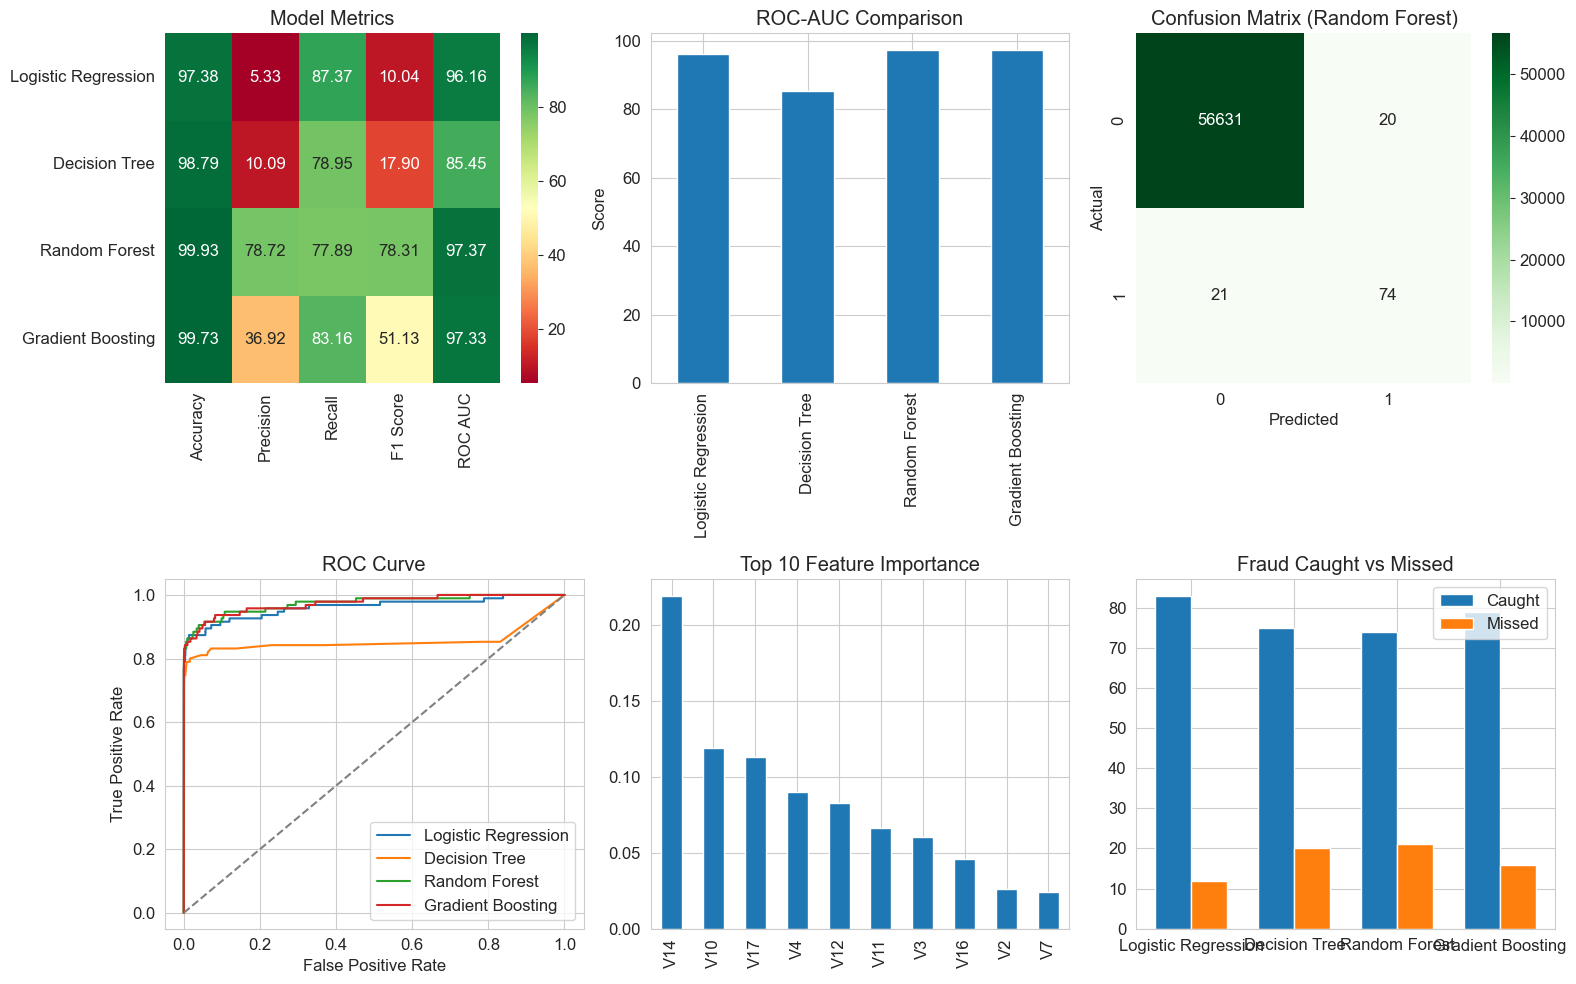

In [54]:
# --- 11.3 Final Dashboard Chart ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve

# Convert metrics to float (fix heatmap error)
results_df[metrics] = results_df[metrics].astype(float)

plt.figure(figsize=(16,10))

# Metrics Heatmap

plt.subplot(2,3,1)

sns.heatmap(results_df[metrics],
            annot=True,
            cmap="RdYlGn",
            fmt=".2f")

plt.title("Model Metrics")


# ROC-AUC Comparison

plt.subplot(2,3,2)

results_df["ROC AUC"].plot(kind="bar")

plt.title("ROC-AUC Comparison")
plt.ylabel("Score")


# Confusion Matrix (Best Model)

plt.subplot(2,3,3)

cm = confusion_matrix(y_test, best_res["y_pred"])

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.title(f"Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")


# ROC Curve

plt.subplot(2,3,4)

for model, res in results.items():
    
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    
    plt.plot(fpr, tpr, label=model)

plt.plot([0,1],[0,1],"--", color="gray")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()


# Feature Importance

plt.subplot(2,3,5)

feat_imp = pd.Series(best_res["model"].feature_importances_, index=X.columns)

feat_imp.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Feature Importance")


# Fraud Caught vs Missed

plt.subplot(2,3,6)

caught = []
missed = []
models = list(results.keys())

for model in models:
    
    tn, fp, fn, tp = confusion_matrix(y_test, results[model]["y_pred"]).ravel()
    
    caught.append(tp)
    missed.append(fn)

x = np.arange(len(models))
width = 0.35

plt.bar(x-width/2, caught, width, label="Caught")
plt.bar(x+width/2, missed, width, label="Missed")

plt.xticks(x, models)
plt.title("Fraud Caught vs Missed")
plt.legend()

plt.tight_layout()

plt.show()